In [1]:
# ============================================================
# Step 9 — Cell 0: LOAD + Step 8 round-trip anchor verification
# ============================================================
import numpy as np
import pandas as pd
import scanpy as sc

adata = sc.read_h5ad("../data/processed/Filbin_step8.h5ad")
TUMORS = ["MUV1", "MUV5", "MUV10", "BCH836", "BCH869", "BCH1126"]

# --- shape / malignant / ambiguous ---
assert adata.shape == (2456, 8494), f"shape drift: {adata.shape}"
mal_mask = adata.obs["is_malignant"].to_numpy(dtype=bool)
assert mal_mask.sum() == 2329, f"malignant {mal_mask.sum()} != 2329"
assert adata.obs["step6_ambiguous"].sum() == 77

# --- Step 7 state still intact ---
assert len(adata.uns["step7"]["signature_names"]) == 60
assert adata.obsm["X_nmf_H"].shape == (2456, 10)

# --- Step 8 payload ---
s8 = adata.uns["step8"]
score_cols = [str(c) for c in s8["meta_score_columns"]]
print("meta_score_columns:", score_cols)

M = adata.obsm["X_meta_scores"]
assert M.shape == (2456, 7), f"X_meta_scores shape {M.shape}"
assert np.isfinite(M[mal_mask]).all(),  "NaN in malignant rows of X_meta_scores"
assert np.isnan(M[~mal_mask]).all(),    "non-NaN in non-malignant rows"

anch = s8["anchors"]
assert int(anch["fourth_subpop_n"]) == 1265
assert adata.obs["step8_fourth_subpop"].sum() == 1265
assert int(anch["P4_total"]) == 159 and int(anch["P4_bio"]) == 70 and int(anch["P4_tech"]) == 89
assert len(s8["OPC_variable"]["genes"]) == 30
for p in ["P1_cellcycle", "P2_AC", "P3_OC"]:
    assert len(s8[p]["genes"]) == 30, f"{p} not 30 genes"

# --- tumor column ---
tumor_col = next((c for c in ["sample","tumor","patient","tumor_id","orig.ident",
                              "sample_id","donor"] if c in adata.obs.columns), None)
assert tumor_col is not None, f"no tumor column in {list(adata.obs.columns)}"
print(f"tumor column: '{tumor_col}'")

# --- meta scores as a malignant-only frame (the Step 9 working object) ---
S = pd.DataFrame(M[mal_mask], columns=score_cols, index=adata.obs_names[mal_mask])
S["tumor"] = adata.obs.loc[mal_mask, tumor_col].to_numpy()
print(f"\n✓ Step 8 anchors hold. Working frame: {S.shape[0]} malignant cells "
      f"× {len(score_cols)} scores")
print(S.groupby("tumor").size().to_string())

meta_score_columns: ['P1_cellcycle', 'P2_AC', 'P3_OC', 'P4_bio70', 'P4_all159', 'OPC_variable_score', 'immune_probe']
tumor column: 'sample'

✓ Step 8 anchors hold. Working frame: 2329 malignant cells × 7 scores
tumor
BCH1126    263
BCH836     441
BCH869     489
MUV1       146
MUV10      286
MUV5       704


In [ ]:
# ============================================================
# Step 9 — Cell 1: DIAGNOSTICS for the three open Step 9 forks.
# Computes both candidate variants of every underspecified
# choice and reports what distinguishes them.
# ============================================================
import numpy as np
import pandas as pd

P1 = S["P1_cellcycle"].to_numpy()
P2 = S["P2_AC"].to_numpy()
P3 = S["P3_OC"].to_numpy()
P4b = S["P4_bio70"].to_numpy()
P4a = S["P4_all159"].to_numpy()

# ---------- FORK A: which P4 for the stemness axis? ----------
stem_bio = P4b - np.maximum(P2, P3)
stem_all = P4a - np.maximum(P2, P3)
print("=== FORK A — stemness axis substrate ===")
for nm, v in [("P4_bio70", stem_bio), ("P4_all159", stem_all)]:
    print(f"  {nm:10s}: range [{v.min():+.2f}, {v.max():+.2f}] "
          f"mean {v.mean():+.3f} | stemness>0: {(v>0).sum():4d} "
          f"({(v>0).mean():.1%})")
print(f"  corr(bio70, all159) stemness = {np.corrcoef(stem_bio, stem_all)[0,1]:.3f}")
print(f"  Filbin Fig.2C y-axis spans about [-8, +4] — compare ranges above.")

# ---------- FORK B: lineage score form ----------
D = P3 - P2                                   # + = OC-like, - = AC-like
lin_raw  = D
lin_slog = np.sign(D) * np.log2(np.abs(D) + 1)   # Tirosh-style signed log
print("\n=== FORK B — lineage score form (D = P3_OC − P2_AC) ===")
for nm, v in [("raw D", lin_raw), ("signed log2", lin_slog)]:
    print(f"  {nm:12s}: range [{v.min():+.2f}, {v.max():+.2f}] "
          f"IQR [{np.percentile(v,25):+.2f}, {np.percentile(v,75):+.2f}]")
print("  Filbin Fig.2C x-axis spans about [-6, +6] — only one of these can fill it.")

# ---------- FORK C: does P3 cancel P4 in the max() term? ----------
s8_genes = {p: [str(g) for g in adata.uns["step8"][p]["genes"]]
            for p in ["P1_cellcycle", "P2_AC", "P3_OC"]}
P4_all = [str(g) for g in adata.uns["step8"]["P4_OPCshared"]["genes"]]
P4_tech = np.asarray(adata.uns["step8"]["P4_OPCshared"]["technical"], dtype=bool)
P4_bio_genes = [g for g, t in zip(P4_all, P4_tech) if not t]

ov_P3_P4 = sorted(set(s8_genes["P3_OC"]) & set(P4_bio_genes))
print("\n=== FORK C — P3_OC / P4 independence ===")
print(f"  gene overlap P3_OC(30) ∩ P4_bio70: {len(ov_P3_P4)} → {ov_P3_P4}")
print(f"  score corr(P3_OC, P4_bio70) = {np.corrcoef(P3, P4b)[0,1]:+.3f}")
print(f"  score corr(P2_AC,  P4_bio70) = {np.corrcoef(P2, P4b)[0,1]:+.3f}")
print("  (strong NEGATIVE corr = clean separation; near 0 or positive = P3 still")
print("   carries OPC signal and will inflate max(), compressing stemness)")

# ---------- the paper's central falsifiable claim ----------
print("\n=== Filbin's core Fig.2C claim: cycling is restricted to stem-like cells ===")
for thr, lbl in [(0.0, "P1>0 (Fig.2C legend)"), (1.0, "P1>1 (score>1 convention)")]:
    cyc = P1 > thr
    print(f"  {lbl:24s}: n={cyc.sum():4d} | mean stemness(bio70) "
          f"cycling {stem_bio[cyc].mean():+.3f} vs non-cycling "
          f"{stem_bio[~cyc].mean():+.3f} | Δ {stem_bio[cyc].mean()-stem_bio[~cyc].mean():+.3f}")

# ---------- provisional composition under each stemness variant ----------
def compose(stem, lin):
    st = np.where(stem > 0, "OPC-like",
         np.where(lin > 0, "OC-like", "AC-like"))
    return pd.crosstab(S["tumor"].to_numpy(), st, normalize="index").round(3)
print("\n=== provisional per-tumor composition — stemness from P4_bio70 ===")
print(compose(stem_bio, lin_raw).to_string())
print("\n=== provisional per-tumor composition — stemness from P4_all159 ===")
print(compose(stem_all, lin_raw).to_string())

# ---------- Fig.3H inputs (SM-specified thresholds) ----------
undiff = (P2 < 1) & (P3 < 1)
print("\n=== Fig.3H inputs (SM: undifferentiated = <1 for BOTH AC and OC) ===")
fig3h = pd.DataFrame({
    "tumor": S["tumor"].to_numpy(), "undiff": undiff,
    "cyc_gt0": P1 > 0, "cyc_gt1": P1 > 1}).groupby("tumor").mean().round(3)
print(fig3h.to_string())

=== FORK A — stemness axis substrate ===
  P4_bio70  : range [-7.25, +2.01] mean -0.486 | stemness>0: 1266 (54.4%)
  P4_all159 : range [-6.95, +1.60] mean -0.512 | stemness>0: 1197 (51.4%)
  corr(bio70, all159) stemness = 0.987
  Filbin Fig.2C y-axis spans about [-8, +4] — compare ranges above.

=== FORK B — lineage score form (D = P3_OC − P2_AC) ===
  raw D       : range [-6.19, +3.73] IQR [-0.42, +0.91]
  signed log2 : range [-2.85, +2.24] IQR [-0.51, +0.93]
  Filbin Fig.2C x-axis spans about [-6, +6] — only one of these can fill it.

=== FORK C — P3_OC / P4 independence ===
  gene overlap P3_OC(30) ∩ P4_bio70: 0 → []
  score corr(P3_OC, P4_bio70) = -0.244
  score corr(P2_AC,  P4_bio70) = -0.685
  (strong NEGATIVE corr = clean separation; near 0 or positive = P3 still
   carries OPC signal and will inflate max(), compressing stemness)

=== Filbin's core Fig.2C claim: cycling is restricted to stem-like cells ===
  P1>0 (Fig.2C legend)    : n= 626 | mean stemness(bio70) cycling -0.052 

✓ assignment invariant under both lineage forms

=== cell-state counts ===
OPC-like    1266
OC-like      579
AC-like      484

OPC-like total: 1266 (54.4%) | fourth subpop was 1265 (54.3%)


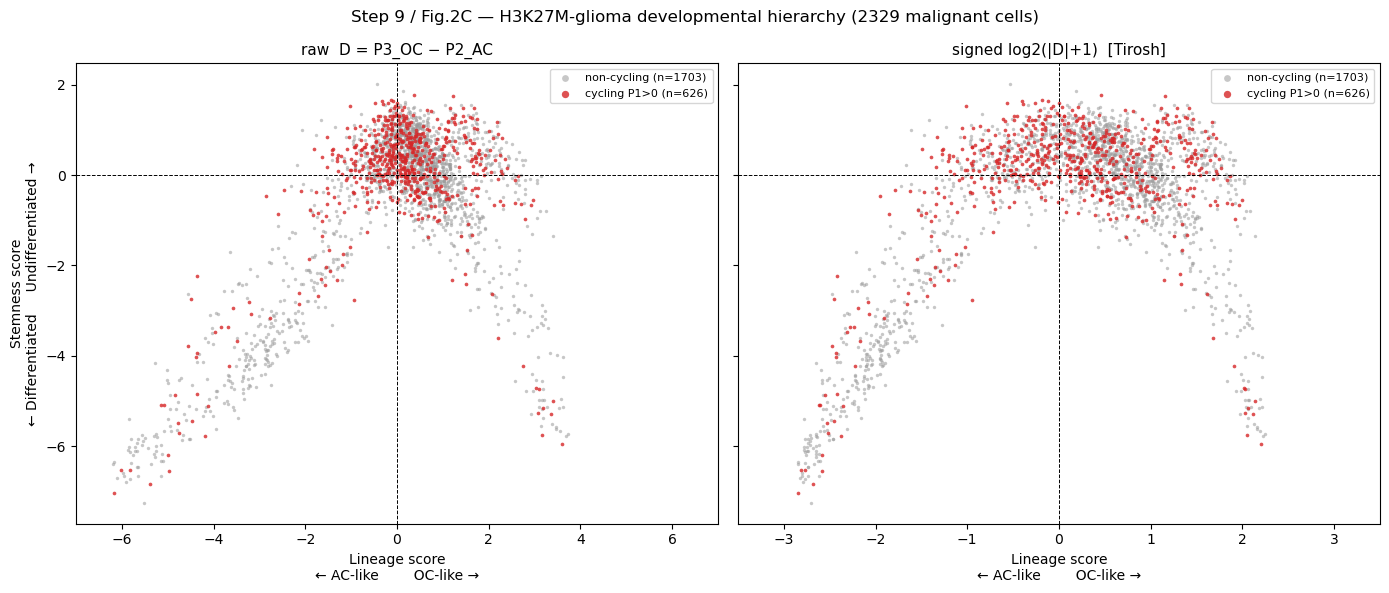


=== cycling fraction by cell state (Filbin: restricted to OPC-like) ===
col_0     False  True 
row_0                 
AC-like   0.795  0.205
OC-like   0.788  0.212
OPC-like  0.681  0.319


In [3]:
# ============================================================
# Step 9 — Cell 2: lock stemness/lineage, three-way cell-state
# assignment, and Fig.2C in BOTH lineage forms (Fork B by eye).
# Computes into local vars only — nothing written to adata yet.
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("../figures/step9", exist_ok=True)

# --- LOCKED: Fork A = P4_bio70 ; Fork C = P3_OC as-is ---
P1 = S["P1_cellcycle"].to_numpy()
P2 = S["P2_AC"].to_numpy()
P3 = S["P3_OC"].to_numpy()
P4 = S["P4_bio70"].to_numpy()

stemness = P4 - np.maximum(P2, P3)
D = P3 - P2
lineage_raw  = D
lineage_slog = np.sign(D) * np.log2(np.abs(D) + 1)

cycling = P1 > 0.0          # Fig.2C legend: positive cell-cycle score

# --- three-way state (invariant to Fork B: sign(D) preserved) ---
state = np.where(stemness > 0, "OPC-like",
         np.where(D > 0, "OC-like", "AC-like"))
assert (np.where(stemness > 0, "OPC-like",
        np.where(lineage_slog > 0, "OC-like", "AC-like")) == state).all(), \
       "Fork B changed the assignment — should be impossible (monotonic)"
print("✓ assignment invariant under both lineage forms")

print("\n=== cell-state counts ===")
print(pd.Series(state).value_counts().to_string())
print(f"\nOPC-like total: {(state=='OPC-like').sum()} "
      f"({(state=='OPC-like').mean():.1%}) | fourth subpop was 1265 (54.3%)")

# --- Fig.2C, both lineage forms ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, lin, ttl, xl in [
        (axes[0], lineage_raw,  "raw  D = P3_OC − P2_AC",        (-7, 7)),
        (axes[1], lineage_slog, "signed log2(|D|+1)  [Tirosh]",  (-3.5, 3.5))]:
    ax.scatter(lin[~cycling], stemness[~cycling], s=6, c="#9a9a9a",
               alpha=.55, lw=0, label=f"non-cycling (n={(~cycling).sum()})")
    ax.scatter(lin[cycling],  stemness[cycling],  s=7, c="#d62728",
               alpha=.80, lw=0, label=f"cycling P1>0 (n={cycling.sum()})")
    ax.axhline(0, color="k", lw=.7, ls="--")
    ax.axvline(0, color="k", lw=.7, ls="--")
    ax.set_xlim(*xl)
    ax.set_xlabel("Lineage score\n← AC-like        OC-like →")
    ax.set_title(ttl, fontsize=11)
    ax.legend(loc="upper right", fontsize=8, markerscale=2)
axes[0].set_ylabel("Stemness score\n← Differentiated     Undifferentiated →")
fig.suptitle("Step 9 / Fig.2C — H3K27M-glioma developmental hierarchy "
             f"({len(stemness)} malignant cells)", fontsize=12)
plt.tight_layout()
plt.savefig("../figures/step9/step9_fig2C_hierarchy_bothlineage.png",
            dpi=150, bbox_inches="tight")
plt.show()

# --- falsifiable: is cycling concentrated in the stem compartment? ---
print("\n=== cycling fraction by cell state (Filbin: restricted to OPC-like) ===")
print(pd.crosstab(state, cycling, normalize="index").round(3).to_string())

=== fig.S13 — per-tumor cell-state composition ===
col_0    OPC-like  AC-like  OC-like
row_0                              
MUV5         65.9     13.4     20.7
BCH1126      65.4     13.7     20.9
BCH836       58.3     15.4     26.3
BCH869       49.7     39.1     11.2
MUV10        36.4     22.4     41.3
MUV1         17.8     21.2     61.0

OPC-like is the plurality in 4/6 tumors
  non-OPC-plurality tumors: {'MUV10': 'OC-like', 'MUV1': 'OC-like'}


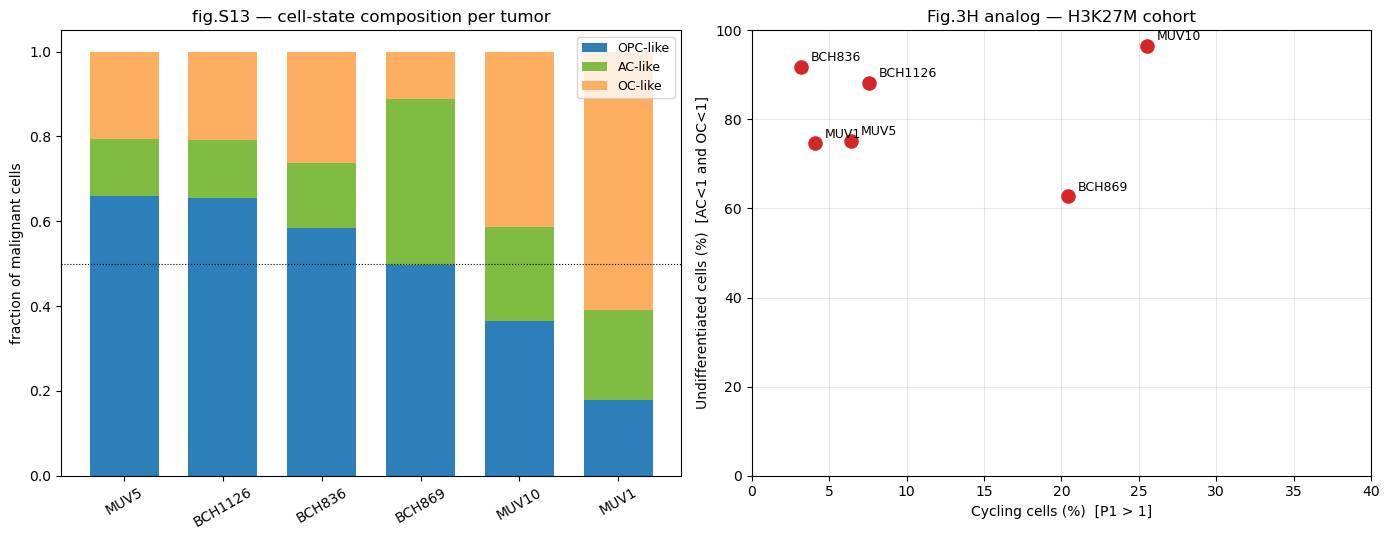


=== Fig.3H values (Filbin K27M reference: ~15-35% cycling, ~60-100% undiff) ===
         undiff  cycling
tumor                   
BCH1126    88.2      7.6
BCH836     91.8      3.2
BCH869     62.8     20.4
MUV1       74.7      4.1
MUV10      96.5     25.5
MUV5       75.1      6.4


In [4]:
# ============================================================
# Step 9 — Cell 3: fig.S13 per-tumor composition (the "OPC-like
# most prevalent" claim) + Fig.3H cycling% vs undifferentiated%.
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

tum = S["tumor"].to_numpy()
comp = pd.crosstab(tum, state, normalize="index")[["OPC-like", "AC-like", "OC-like"]]
comp = comp.loc[comp["OPC-like"].sort_values(ascending=False).index]
print("=== fig.S13 — per-tumor cell-state composition ===")
print((comp * 100).round(1).to_string())

plurality = comp.idxmax(axis=1)
n_opc_plur = (plurality == "OPC-like").sum()
print(f"\nOPC-like is the plurality in {n_opc_plur}/6 tumors")
print("  non-OPC-plurality tumors:",
      {t: plurality[t] for t in comp.index if plurality[t] != "OPC-like"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- fig.S13 stacked bars ---
ax = axes[0]
bottom = np.zeros(len(comp))
for st, col in [("OPC-like", "#2c7fb8"), ("AC-like", "#7fbc41"), ("OC-like", "#fdae61")]:
    ax.bar(comp.index, comp[st], bottom=bottom, color=col, label=st, width=.7)
    bottom += comp[st].to_numpy()
ax.axhline(.5, color="k", lw=.8, ls=":")
ax.set_ylabel("fraction of malignant cells")
ax.set_title("fig.S13 — cell-state composition per tumor")
ax.legend(fontsize=9)
ax.tick_params(axis="x", rotation=30)

# --- Fig.3H: cycling% (x) vs undifferentiated% (y), SM thresholds ---
undiff = (P2 < 1) & (P3 < 1)
h = pd.DataFrame({"tumor": tum, "undiff": undiff, "cycling": P1 > 1}) \
      .groupby("tumor").mean() * 100
ax = axes[1]
ax.scatter(h["cycling"], h["undiff"], s=90, c="#d62728", zorder=3)
for t, r in h.iterrows():
    ax.annotate(t, (r["cycling"], r["undiff"]), textcoords="offset points",
                xytext=(7, 4), fontsize=9)
ax.set_xlabel("Cycling cells (%)  [P1 > 1]")
ax.set_ylabel("Undifferentiated cells (%)  [AC<1 and OC<1]")
ax.set_title("Fig.3H analog — H3K27M cohort")
ax.set_xlim(0, 40); ax.set_ylim(0, 100)
ax.grid(alpha=.3)

plt.tight_layout()
plt.savefig("../figures/step9/step9_figS13_fig3H.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Fig.3H values (Filbin K27M reference: ~15-35% cycling, ~60-100% undiff) ===")
print(h.round(1).to_string())

In [5]:
# ============================================================
# Step 9 — Cell 3b: FORK D (assignment rule) + the actual
# fig.S13A comparison (composition AMONG cycling cells).
# Diagnostic only — nothing frozen.
# ============================================================
import numpy as np
import pandas as pd

# --- Rule 1 (current): sign of stemness, then sign of D ---
state_sign = np.where(stemness > 0, "OPC-like",
              np.where(D > 0, "OC-like", "AC-like"))

# --- Rule 2 (SM-anchored): undifferentiated = AC<1 AND OC<1 ---
undiff_abs = (P2 < 1) & (P3 < 1)
state_abs = np.where(undiff_abs, "OPC-like",
             np.where(P3 > P2, "OC-like", "AC-like"))

print("=== FORK D — assignment rule comparison ===")
for nm, st in [("Rule 1  sign(stemness)", state_sign),
               ("Rule 2  SM abs AC<1&OC<1", state_abs)]:
    vc = pd.Series(st).value_counts()
    print(f"\n{nm}: OPC {vc.get('OPC-like',0)} "
          f"({vc.get('OPC-like',0)/len(st):.1%}) | "
          f"AC {vc.get('AC-like',0)} | OC {vc.get('OC-like',0)}")
    comp = pd.crosstab(tum, st, normalize="index")
    comp = comp.reindex(columns=["OPC-like","AC-like","OC-like"], fill_value=0)
    print((comp*100).round(1).to_string())
    plur = comp.idxmax(axis=1)
    print(f"  OPC-like plurality in {(plur=='OPC-like').sum()}/6 tumors"
          + ("" if (plur=='OPC-like').all()
             else f"  exceptions: {{{', '.join(f'{t}:{plur[t]}' for t in comp.index if plur[t]!='OPC-like')}}}"))

print("\n=== rule agreement ===")
print(pd.crosstab(state_sign, state_abs,
                  rownames=["sign(stemness)"], colnames=["SM absolute"]).to_string())
print(f"agreement: {(state_sign==state_abs).mean():.1%}")

# --- fig.S13A BOTTOM PANEL: composition among CYCLING cells only ---
print("\n" + "="*62)
print("fig.S13A — 'OPC-like cells are ... the source of cycling cells'")
print("="*62)
for thr in [0.0, 1.0]:
    cyc = P1 > thr
    print(f"\n--- cycling = P1 > {thr} (n={cyc.sum()}) ---")
    for nm, st in [("Rule 1", state_sign), ("Rule 2", state_abs)]:
        allc = pd.Series(st).value_counts(normalize=True)
        cycc = pd.Series(st[cyc]).value_counts(normalize=True)
        row = pd.DataFrame({"all cells %": (allc*100).round(1),
                            "cycling cells %": (cycc*100).round(1)})
        row["enrichment"] = (row["cycling cells %"]/row["all cells %"]).round(2)
        print(f"\n  {nm}:")
        print(row.reindex(["OPC-like","AC-like","OC-like"]).to_string())

# --- per-state cycling RATE (the stricter claim) ---
print("\n=== per-state cycling rate (is proliferation RESTRICTED?) ===")
for thr in [0.0, 1.0]:
    cyc = P1 > thr
    r1 = pd.crosstab(state_sign, cyc, normalize="index")[True] if cyc.any() else None
    r2 = pd.crosstab(state_abs,  cyc, normalize="index")[True]
    print(f"\n  P1>{thr}: Rule1 " +
          " ".join(f"{s} {r1[s]:.1%}" for s in ["OPC-like","AC-like","OC-like"]))
    print(f"          Rule2 " +
          " ".join(f"{s} {r2[s]:.1%}" for s in ["OPC-like","AC-like","OC-like"]))

=== FORK D — assignment rule comparison ===

Rule 1  sign(stemness): OPC 1266 (54.4%) | AC 484 | OC 579
col_0    OPC-like  AC-like  OC-like
row_0                              
BCH1126      65.4     13.7     20.9
BCH836       58.3     15.4     26.3
BCH869       49.7     39.1     11.2
MUV1         17.8     21.2     61.0
MUV10        36.4     22.4     41.3
MUV5         65.9     13.4     20.7
  OPC-like plurality in 4/6 tumors  exceptions: {MUV1:OC-like, MUV10:OC-like}

Rule 2  SM abs AC<1&OC<1: OPC 1858 (79.8%) | AC 320 | OC 151
col_0    OPC-like  AC-like  OC-like
row_0                              
BCH1126      88.2      5.3      6.5
BCH836       91.8      6.8      1.4
BCH869       62.8     34.4      2.9
MUV1         74.7     11.0     14.4
MUV10        96.5      1.0      2.4
MUV5         75.1     12.6     12.2
  OPC-like plurality in 6/6 tumors

=== rule agreement ===
SM absolute     AC-like  OC-like  OPC-like
sign(stemness)                            
AC-like             320        0   

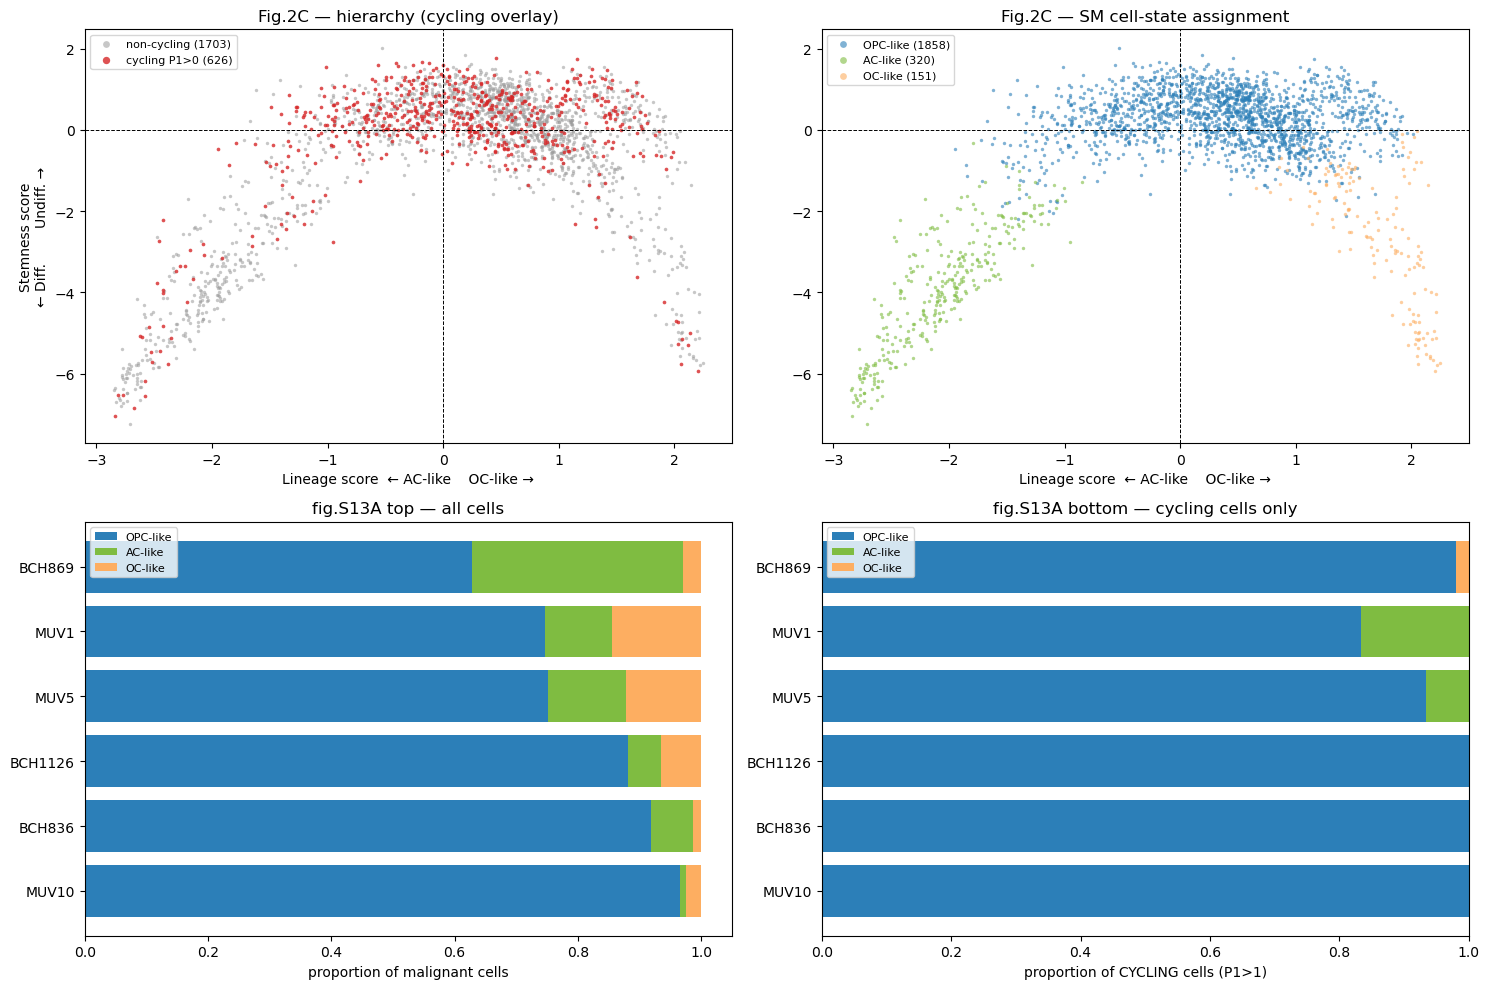

=== fig.S13A bottom — per-tumor cycling composition (%) ===
col_0    OPC-like  AC-like  OC-like
row_0                              
MUV10       100.0      0.0      0.0
BCH836      100.0      0.0      0.0
BCH1126     100.0      0.0      0.0
MUV5         93.3      6.7      0.0
MUV1         83.3     16.7      0.0
BCH869       98.0      0.0      2.0

cycling cells per tumor (P1>1): {'BCH869': 100, 'MUV10': 73, 'MUV5': 45, 'BCH1126': 20, 'BCH836': 14, 'MUV1': 6}


In [6]:
# ============================================================
# Step 9 — Cell 4: final Fig.2C + fig.S13 (Rule 2 assignment),
# and fig.S13A bottom panel (composition among cycling cells).
# ============================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt

state_final = state_abs                 # Rule 2, SM-anchored
cycling_plot = P1 > 0.0                 # Fig.2C legend
cycling_call = P1 > 1.0                 # classification (S13A, 3H)

COL = {"OPC-like": "#2c7fb8", "AC-like": "#7fbc41", "OC-like": "#fdae61"}
fig = plt.figure(figsize=(15, 10))

# --- (a) Fig.2C, coloured by cycling ---
ax = fig.add_subplot(2, 2, 1)
ax.scatter(lineage_slog[~cycling_plot], stemness[~cycling_plot], s=6,
           c="#9a9a9a", alpha=.55, lw=0, label=f"non-cycling ({(~cycling_plot).sum()})")
ax.scatter(lineage_slog[cycling_plot], stemness[cycling_plot], s=7,
           c="#d62728", alpha=.8, lw=0, label=f"cycling P1>0 ({cycling_plot.sum()})")
ax.axhline(0, color="k", lw=.7, ls="--"); ax.axvline(0, color="k", lw=.7, ls="--")
ax.set_xlabel("Lineage score  ← AC-like    OC-like →")
ax.set_ylabel("Stemness score\n← Diff.        Undiff. →")
ax.set_title("Fig.2C — hierarchy (cycling overlay)"); ax.legend(fontsize=8, markerscale=2)

# --- (b) Fig.2C, coloured by frozen cell state ---
ax = fig.add_subplot(2, 2, 2)
for st in ["OPC-like", "AC-like", "OC-like"]:
    m = state_final == st
    ax.scatter(lineage_slog[m], stemness[m], s=6, c=COL[st], alpha=.6, lw=0,
               label=f"{st} ({m.sum()})")
ax.axhline(0, color="k", lw=.7, ls="--"); ax.axvline(0, color="k", lw=.7, ls="--")
ax.set_xlabel("Lineage score  ← AC-like    OC-like →")
ax.set_title("Fig.2C — SM cell-state assignment"); ax.legend(fontsize=8, markerscale=2)

# --- (c) fig.S13A top: composition all cells ---
comp_all = pd.crosstab(tum, state_final, normalize="index")
comp_all = comp_all.reindex(columns=["OPC-like","AC-like","OC-like"], fill_value=0)
comp_all = comp_all.loc[comp_all["OPC-like"].sort_values(ascending=False).index]
ax = fig.add_subplot(2, 2, 3)
bottom = np.zeros(len(comp_all))
for st in ["OPC-like","AC-like","OC-like"]:
    ax.barh(comp_all.index, comp_all[st], left=bottom, color=COL[st], label=st)
    bottom += comp_all[st].to_numpy()
ax.set_xlabel("proportion of malignant cells")
ax.set_title("fig.S13A top — all cells"); ax.legend(fontsize=8)

# --- (d) fig.S13A bottom: composition among cycling cells ---
comp_cyc = pd.crosstab(tum[cycling_call], state_final[cycling_call], normalize="index")
comp_cyc = comp_cyc.reindex(index=comp_all.index,
                            columns=["OPC-like","AC-like","OC-like"], fill_value=0)
ax = fig.add_subplot(2, 2, 4)
bottom = np.zeros(len(comp_cyc))
for st in ["OPC-like","AC-like","OC-like"]:
    ax.barh(comp_cyc.index, comp_cyc[st], left=bottom, color=COL[st], label=st)
    bottom += comp_cyc[st].to_numpy()
ax.set_xlabel("proportion of CYCLING cells (P1>1)")
ax.set_title("fig.S13A bottom — cycling cells only"); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../figures/step9/step9_fig2C_figS13_final.png", dpi=150, bbox_inches="tight")
plt.show()

print("=== fig.S13A bottom — per-tumor cycling composition (%) ===")
print((comp_cyc*100).round(1).to_string())
print(f"\ncycling cells per tumor (P1>1): "
      f"{pd.Series(tum[cycling_call]).value_counts().to_dict()}")

# Step 9 — Stemness / lineage hierarchy (Fig. 2C, fig. S13, Fig. 3H)

## What we did
Closed Phase 1 by placing every malignant cell on Filbin's two-dimensional
hierarchy and classifying it into a cell state. Step 9 introduced **no new
scoring** — it is a pure transform of `obsm["X_meta_scores"]` frozen in Step 8,
so it is fully deterministic given Step 8.

1. **Stemness axis (SM-explicit).** `stemness = SC(P4) − max(SC(P2_AC), SC(P3_OC))`.
   The SM states this verbatim ("expression of the OPC-shared program minus the
   maximal expression of the two differentiation programs").
2. **Lineage axis (SM-silent).** Filbin gives no formula, only that differentiated
   cells are "classified by a lineage score distinguishing the oligodendrocytic
   from astrocytic lineages". Adopted the Tirosh 2016 convention:
   `lineage = sign(D)·log2(|D|+1)`, `D = SC(P3_OC) − SC(P2_AC)`, positive = OC.
3. **Cell-state assignment.** Undifferentiated (OPC-like) if `AC<1 AND OC<1`;
   otherwise OC-like if `P3>P2`, else AC-like. This is the SM's own Fig. 3H
   threshold, applied as the classification rule.
4. **Cycling.** Two thresholds retained for two purposes (D14).
5. Reproduced fig. S13A (composition, all cells and cycling cells) and the
   Fig. 3H analog (cycling % vs undifferentiated % per tumor).

## Decisions made (D12–D14)

**D12 — axis construction.** Three forks, each resolved on a measured quantity:
- *Which P4?* **biological-70**, not all-159. Decisive number: stemness>0 selects
  1,266 cells against the Step 8 fourth subpopulation's 1,265 — two independent
  derivations (a score-threshold intersection vs. a difference-of-scores) landing
  one cell apart. `P4_all159` gives 1,197 and does not reproduce it. The two
  stemness vectors correlate 0.987, so this is a small fork, but a decidable one.
- *Lineage form?* **Tirosh signed log2**. Monotonic in `D`, therefore the cell-state
  assignment is **provably invariant** to this choice (asserted in code, not assumed).
  It compresses the axis to ±2.85 against Filbin's ±6 — expected under the transform,
  *not* a scale error. Raw `D` also frozen (`obs["step9_lineage_raw"]`) for
  side-by-side figure comparison with the published panel.
- *P3 in the `max()` term?* **as-is**. Our P3 is oligodendroglial-broad by design
  (9/30 Table S5), so we checked whether it would cancel P4 and compress stemness:
  gene overlap with P4_bio70 is **0**, score correlation **−0.244** (vs AC's −0.685).
  No cancellation mechanism exists. Purging would have solved a non-problem.

**D13 — assignment rule (the substantive decision).** Our first rule — `sign(stemness)`,
then `sign(D)` — gave OPC-like plurality in only **4/6** tumors (MUV1 and MUV10 came
out OC-dominant), contradicting Filbin's "OPC-like cells were consistently the most
prevalent". Before logging that as a cohort deviation we re-read the SM, and figs.
S13/S17E label the three states "**Undiff., OPC-like**" / "Diff., AC-like" /
"Diff., OC-like" — i.e. OPC-like *is* the undifferentiated compartment, for which
the SM states exactly one criterion (`AC<1 and OC<1`). Switching to it gives **6/6**.

The two rules are strictly **nested**: every cell the sign rule calls OPC-like the
SM rule also calls OPC-like (1,266 ⊂ 1,858; zero cross-assignment in the crosstab).
The 592 additional cells are weakly-differentiated ones that the sign rule force-binned
into the arms on near-zero margins. Root cause: stemness is a *relative* quantity
(a difference of scores) while the SM criterion is *absolute*; in a tumor with little
differentiation — Filbin's own text notes some tumors had little evidence of it —
all three scores sit low and the difference rule manufactures structure. MUV10 is the
extreme case: 96.5% undifferentiated by the SM threshold, 36.4% by the sign rule.
**The 4/6 result was an artifact of our rule, not a property of the cohort.**
The sign rule is retained as `obs["step9_state_stemness_sign"]`, not used for composition.

**D14 — cycling thresholds.** Both kept, for different figures. `P1>0` for the Fig. 2C
red-dot overlay (the Fig. 2C legend specifies a *positive* score; n=626). `P1>1` for
classification in fig. S13A and Fig. 3H (n=258). This matters: "proliferation largely
restricted to OPC-like" holds at `P1>1` (97.7% of cycling cells OPC-like; per-state
rate 13.6% vs 1.2%/1.3%, >10×) but is only mild enrichment at `P1>0` (89.5%, ~2×).
Threshold reported alongside the claim.

## What we found
- **Hierarchy topology reproduces.** The inverted-V of Fig. 2C: an undifferentiated
  apex with two arms descending toward the AC-like and OC-like poles.
- **Composition:** OPC-like 1,858 (79.8%), AC-like 320 (13.7%), OC-like 151 (6.5%).
  **OPC-like is the plurality in 6/6 tumors** — Filbin's central claim, reproduced.
  Per-tumor undifferentiated fraction 62.8–96.5%.
- **Cycling is confined to the stem compartment:** 97.7% of cycling cells are
  OPC-like; per-state cycling rate 13.6% (OPC) vs 1.2% (AC) / 1.3% (OC).
- **Fig. 3H:** cycling 3.2–25.5%, undifferentiated 62.8–96.5% — inside the published
  K27M band. BCH869 and MUV10 are the high-cycling samples (20.4%, 25.5%).
- **Caveat (§G.8):** per-tumor cycling denominators are small — MUV1 n=6, BCH836 n=14,
  BCH1126 n=20. The 100% OPC-like bars for those tumors are underpowered. **Quote the
  pooled 97.7% of 258; treat the per-tumor bars as illustrative.**

## Figure — `step9_fig2C_figS13_final.png`

Four panels.

**Top-left (Fig. 2C, cycling overlay).** Lineage (x) vs stemness (y) for all 2,329
malignant cells; red = cycling (`P1>0`). Reproduces the inverted-V. Red is dense across
the undifferentiated apex and sparse down both differentiated arms — the visual form of
"proliferation largely restricted to OPC-like cells". The residual red in the arm tails
is why the claim is stated at `P1>1` rather than `P1>0` (D14).

**Top-right (Fig. 2C, cell states).** Same axes, coloured by the frozen SM assignment.
This panel is the visual proof of D13: **blue (OPC-like) extends well below stemness 0,
down to about −2**. Those are the 592 cells the sign rule would have pushed into the
green and orange arms. The SM rule keeps them undifferentiated because their *absolute*
AC and OC scores never reach 1, regardless of which is marginally larger. Note also that
the green and orange populations occupy the arm tips only — genuine differentiation, not
a partition of the middle.

**Bottom-left (fig. S13A top).** Per-tumor composition, all cells, sorted by OPC-like
fraction (bars run bottom-to-top: MUV10 highest, BCH869 lowest). OPC-like is the
majority everywhere. BCH869 carries the largest AC-like compartment (34.4%), MUV1 the
largest OC-like (14.4%).

**Bottom-right (fig. S13A bottom).** Composition among cycling cells only (`P1>1`).
Near-uniform blue — the differentiated compartments contribute almost no proliferation.
Read with the denominators above: MUV10/BCH836/BCH1126 at 100% rest on 73/14/20 cells.

Lineage axis is the signed-log form (D12); for a side-by-side against the published
Fig. 2C, regenerate with `obs["step9_lineage_raw"]` to match the ±6 axis and say so in
the caption.

## Frozen
`data/processed/Filbin_step9.h5ad` — round-trip verified. Adds `step9_stemness`,
`step9_lineage`, `step9_lineage_raw`, `step9_state`, `step9_state_stemness_sign`,
`step9_cycling`, and `uns["step9"]` (definitions, composition tables, Fig. 3H values,
anchors, D12–D14 full text). All Step 7 and Step 8 state preserved.

**Phase 1 complete.**